# Set Up

In [484]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import os
import matplotlib as plt

In [485]:
file_path = "anime.csv"

path = kagglehub.dataset_download("hernan4444/anime-recommendation-database-2020")
print("Dataset path:", path)

Dataset path: C:\Users\rdjg2\.cache\kagglehub\datasets\hernan4444\anime-recommendation-database-2020\versions\7


In [486]:
anime_path = os.path.join(path, "anime.csv")

anime = pd.read_csv(
    anime_path,
    encoding="latin1",
    sep=",",
    engine="python",
    on_bad_lines="skip"
)

print(anime.head())
print(anime.shape)

   MAL_ID                             Name Score  \
0       1                     Cowboy Bebop  8.78   
1       5  Cowboy Bebop: Tengoku no Tobira  8.39   
2       6                           Trigun  8.24   
3       7               Witch Hunter Robin  7.27   
4       8                   Bouken Ou Beet  6.98   

                                              Genres            English name  \
0    Action, Adventure, Comedy, Drama, Sci-Fi, Space            Cowboy Bebop   
1              Action, Drama, Mystery, Sci-Fi, Space  Cowboy Bebop:The Movie   
2  Action, Sci-Fi, Adventure, Comedy, Drama, Shounen                  Trigun   
3  Action, Mystery, Police, Supernatural, Drama, ...      Witch Hunter Robin   
4          Adventure, Fantasy, Shounen, Supernatural  Beet the Vandel Buster   

                                       Japanese name   Type Episodes  \
0                        ã«ã¦ãã¼ã¤ãããã     TV       26   
1           ã«ã¦ãã¼ã¤ãããã å¤©å½ã®æ  Movie   

In [487]:
rating_path = os.path.join(path, "animelist.csv")

ratings = pd.read_csv(
    rating_path,
    encoding="latin1"
)

print(ratings.head())
print(ratings.shape)

   user_id  anime_id  rating  watching_status  watched_episodes
0        0        67       9                1                 1
1        0      6702       7                1                 4
2        0       242      10                1                 4
3        0      4898       0                1                 1
4        0        21      10                1                 0
(109224747, 5)


In [488]:
watching_status_path = os.path.join(path, "watching_status.csv")
# This just shows what each number in the watching status in the previous dataset means

status = pd.read_csv(
    watching_status_path,
    encoding="latin1",
    sep=",",
    engine="python",
    on_bad_lines="skip"
)

print(status.head())
print(status.shape)

   status         description
0       1  Currently Watching
1       2           Completed
2       3             On Hold
3       4             Dropped
4       6       Plan to Watch
(5, 2)


# EDA

## Animes

In [489]:
anime.info()

<class 'pandas.DataFrame'>
RangeIndex: 17562 entries, 0 to 17561
Data columns (total 35 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   MAL_ID         17562 non-null  int64
 1   Name           17562 non-null  str  
 2   Score          17562 non-null  str  
 3   Genres         17562 non-null  str  
 4   English name   17562 non-null  str  
 5   Japanese name  17562 non-null  str  
 6   Type           17562 non-null  str  
 7   Episodes       17562 non-null  str  
 8   Aired          17562 non-null  str  
 9   Premiered      17562 non-null  str  
 10  Producers      17562 non-null  str  
 11  Licensors      17562 non-null  str  
 12  Studios        17562 non-null  str  
 13  Source         17562 non-null  str  
 14  Duration       17562 non-null  str  
 15  Rating         17562 non-null  str  
 16  Ranked         17562 non-null  str  
 17  Popularity     17562 non-null  int64
 18  Members        17562 non-null  int64
 19  Favorites      

In [490]:
anime.isnull().sum()

MAL_ID           0
Name             0
Score            0
Genres           0
English name     0
Japanese name    0
Type             0
Episodes         0
Aired            0
Premiered        0
Producers        0
Licensors        0
Studios          0
Source           0
Duration         0
Rating           0
Ranked           0
Popularity       0
Members          0
Favorites        0
Watching         0
Completed        0
On-Hold          0
Dropped          0
Plan to Watch    0
Score-10         0
Score-9          0
Score-8          0
Score-7          0
Score-6          0
Score-5          0
Score-4          0
Score-3          0
Score-2          0
Score-1          0
dtype: int64

---
We can observe that the dataset is already processed, showing a dataset with no missing values.

Is probable that some columns that are string have a "NaN" or "Unknown" type, so we will need to take that into account.

---

### Dropping Columns

---
First, we will drop some columns that do not provide useful information:

    - Japanese name
    - English name

And we will perform a simple analysis of the following columns: 

    - Premiered
    - Licensors
    - Producers
    - Source

This will allow us to observe what columns do not provide important information, making the cleaning and processing of the dataset faster.


---

In [491]:
# We will work on a copy of the original dataset, in case we want to revisit the original.
anime_processed = anime.copy()

#### Japanese name

In [492]:
anime_processed = anime_processed.drop(columns=["Japanese name"])

#### English name

In [493]:
anime_processed = anime_processed.drop(columns=["English name"])

#### Premiered

In [494]:
anime["Premiered"].value_counts().head(30)

Premiered
Unknown        12817
Spring 2017       86
Fall 2016         79
Spring 2018       77
Spring 2016       74
Spring 2006       71
Spring 2014       71
Fall 2017         70
Spring 2011       68
Fall 2015         65
Fall 2018         64
Spring 2015       63
Spring 2020       61
Summer 2018       60
Winter 2021       60
Spring 2007       59
Summer 2015       59
Summer 2017       59
Spring 2012       58
Spring 2013       58
Summer 2016       58
Spring 2019       57
Winter 2018       56
Fall 2019         56
Fall 2020         56
Fall 2006         55
Winter 2014       55
Fall 2014         55
Spring 2021       54
Spring 2008       53
Name: count, dtype: int64

In [495]:
anime["Premiered"].nunique()

231

---
We observe that the majority of the entries presents the Unknown category in this field, making it safe to drop the column.

---

In [496]:
anime_processed = anime_processed.drop(columns=["Premiered"])

#### Licensors

In [497]:
anime["Licensors"].value_counts().head(30)

Licensors
Unknown                                     13616
Funimation                                    883
Sentai Filmworks                              652
Media Blasters                                206
Discotek Media                                194
Aniplex of America                            177
ADV Films                                     149
VIZ Media                                     138
Central Park Media                             86
Bandai Entertainment                           84
Nozomi Entertainment                           75
Geneon Entertainment USA                       55
Funimation, Geneon Entertainment USA           51
NIS America, Inc.                              50
ADV Films, Funimation                          49
Funimation, Crunchyroll                        45
Maiden Japan                                   43
Funimation, Bandai Entertainment               39
Manga Entertainment                            38
The Pokemon Company International       

In [498]:
anime["Licensors"].nunique()

231

---
We observe that most of the entries present an Unknown value in this column so, as before, we can safely drop this column without lossing relevant information.

---

In [499]:
anime_processed = anime_processed.drop(columns=["Licensors"])

#### Producers

In [500]:
anime["Producers"].value_counts().head(30)

Producers
Unknown                     7794
NHK                          623
Pink Pineapple               184
Sanrio                       160
Bandai Visual                117
Fuji TV                      112
Aniplex                      105
TV Tokyo                     102
Gakken                        89
TV Asahi                      86
Tokyo Movie Shinsha           75
Milky Animation Label         67
TBS                           61
Lantis                        56
Pony Canyon                   55
CoMix Wave Films              53
Sotsu                         51
Starchild Records             49
Shueisha                      46
Toy's Factory                 45
Space Shower Music            45
Victor Entertainment          44
Geidai Animation              40
Kadokawa Shoten               39
Tezuka Productions            39
AIC                           38
Tencent Penguin Pictures      38
bilibili                      38
Mary Jane                     37
VAP                           35


In [501]:
anime["Producers"].nunique()

3783

---
We observe a similar scenario as before, but now the number of missing values is lower (althouhg it is still half of the entries).

ALthough this could be important, users wwho wathc anime dont watch it based on the producers, but rather on the studios, so we will drop the column too as the information that we will lose is minimal and not relevant.

---

In [502]:
anime_processed = anime_processed.drop(columns=["Producers"])

#### Source

In [503]:
anime["Source"].value_counts()

Source
Original         5215
Manga            3825
Unknown          3567
Visual novel      993
Game              880
Light novel       768
Other             597
Novel             510
Music             317
4-koma manga      288
Web manga         252
Picture book      147
Book              112
Card game          64
Digital manga      15
Radio              12
Name: count, dtype: int64

In [504]:
anime["Source"].nunique()

16

In [505]:
# We will transform "Unknown" to NaN, to avoid the model thinking that "Unknown" is an important category
anime_processed["Source"] = anime_processed["Source"].replace("Unknown", pd.NA)

---
As Source looks like an informative column, we will keep it and further analyze it in future steps.

---

### Further Preprocessing

#### Genres

In [506]:
anime["Genres"].nunique()

5034

In [507]:
anime["Genres"].head(5)

0      Action, Adventure, Comedy, Drama, Sci-Fi, Space
1                Action, Drama, Mystery, Sci-Fi, Space
2    Action, Sci-Fi, Adventure, Comedy, Drama, Shounen
3    Action, Mystery, Police, Supernatural, Drama, ...
4            Adventure, Fantasy, Shounen, Supernatural
Name: Genres, dtype: str

In [508]:
all_genres = anime["Genres"].str.split(", ").explode()
all_genres.value_counts().head(20)

Genres
Comedy           6029
Action           3888
Fantasy          3285
Adventure        2957
Kids             2665
Drama            2619
Sci-Fi           2583
Music            2244
Shounen          2003
Slice of Life    1914
Romance          1899
School           1642
Supernatural     1479
Hentai           1348
Historical       1144
Mecha            1101
Magic            1081
Seinen            830
Ecchi             767
Mystery           727
Name: count, dtype: int64

In [509]:
anime_processed = anime_processed[~anime_processed["Genres"].str.contains("Hentai", na=False)]

In [510]:
genre_dummies = anime_processed["Genres"].str.get_dummies(", ")
anime_processed = pd.concat([anime_processed, genre_dummies], axis=1)

In [511]:
genre_dummies.shape
genre_dummies.sum().sort_values(ascending=False)

Comedy           5975
Action           3846
Fantasy          3202
Adventure        2942
Kids             2665
Drama            2589
Sci-Fi           2551
Music            2241
Shounen          2003
Slice of Life    1912
Romance          1852
School           1577
Supernatural     1410
Historical       1129
Mecha            1094
Magic            1056
Seinen            830
Ecchi             767
Mystery           721
Sports            708
Shoujo            688
Parody            649
Super Power       627
Military          572
Dementia          510
Space             491
Demons            434
Horror            430
Martial Arts      416
Game              386
Harem             357
Psychological     340
Police            243
Samurai           202
Cars              133
Vampire           133
Thriller          130
Shounen Ai        100
Josei              96
Shoujo Ai          79
Unknown            63
Yaoi               31
dtype: int64

---
We observe that the genre Hentai appears frequently in the dataset. However, it corresponds to explicit adult content, so it will be excluded from the analysis to maintain consistency with the scope of the recommendation system.

---

---
We observe that there are 63 entries with unknown genre, so we will simply drop this entries as the information lost is going to be minimal, since animes with a not known genre are likely to be niche animes. 

This way we will improve the data quality and avoid introducing noise into the model.

---

In [512]:
anime_processed = anime_processed[anime_processed["Unknown"] == 0]
anime_processed = anime_processed.drop(columns=["Unknown"])

In [513]:
anime_processed = anime_processed.drop(columns=["Genres"])

#### Members

In [514]:
anime["Members"].describe()

count    1.756200e+04
mean     3.465854e+04
std      1.252821e+05
min      1.000000e+00
25%      3.360000e+02
50%      2.065000e+03
75%      1.322325e+04
max      2.589552e+06
Name: Members, dtype: float64

<Axes: >

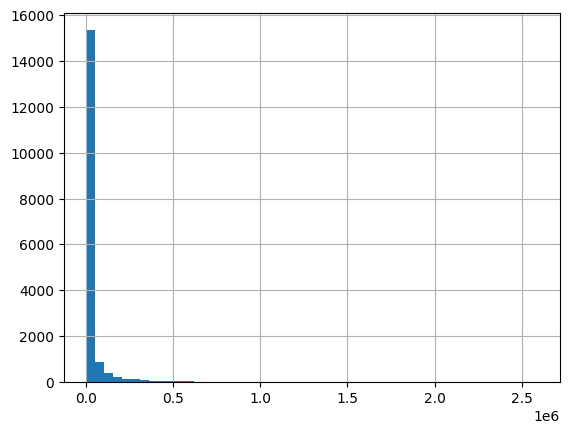

In [515]:
anime["Members"].hist(bins=50)

---
We observe the typical pereto distribution present in almost every dataset with user-item interactions: A few items are being interacted by a large number of users, while the majority of the items are being interacted by few users.

A logarithmic transformation is appropriate to reduce skewness and stabilize variance, making the feature more suitable for modeling.

---

#### Score

In [516]:
anime["Score"].unique()[:10]

<StringArray>
['8.78', '8.39', '8.24', '7.27', '6.98', '7.95', '8.06', '7.59', '8.15',
 '8.76']
Length: 10, dtype: str

In [517]:
anime_processed["Score"] = pd.to_numeric(anime_processed["Score"], errors="coerce")

In [518]:
anime_processed["Score"].isnull().sum()

np.int64(5075)

---
There is a large number of the entries with missing values (~30%). 

Removing these entries would suppose a significant reduction in the dataset size, so we will keep them, and we will use other methods (implicit data) to understand the beahvior of the users towards these entries

---

<Axes: >

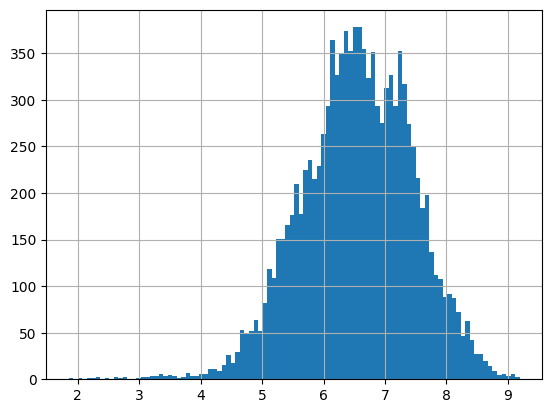

In [519]:
anime_processed["Score"].hist(bins=100)

---
The distribution of the Score is centered around values between 6 and 7, with most animes receiving scores between 5 and 8.

We observe that there are very few animes with low ratings (below 4) , as well as very few animes with high ratings (above 8.75).

This indicates that most anime are rated moderately to highly, and very poor ratings are uncommon.

---

#### Type

In [520]:
anime["Type"].value_counts()

Type
TV         4996
OVA        3894
Movie      3041
Special    2218
ONA        1907
Music      1469
Unknown      37
Name: count, dtype: int64

In [521]:
anime_processed = anime_processed[anime_processed["Type"] != "Unknown"]

---
As the number of animes with unknow in the type column is negligible, we removed them to avoid introducing noise into the model.

---

#### Episodes

In [522]:
anime["Episodes"].unique()

<StringArray>
[     '26',       '1',      '52',     '145',      '24',      '74',     '220',
 'Unknown',     '178',      '12',
 ...
     '139',     '475',    '1306',      '89',     '744',     '120',     '146',
     '122',     '135',     '160']
Length: 201, dtype: str

In [523]:
anime_processed["Episodes"] = pd.to_numeric(anime_processed["Episodes"], errors="coerce")

In [524]:
anime_processed["Episodes"].isnull().sum()

np.int64(440)

---
The Episodes column contains a small proportion of missing values. 

We will remove these entries to ensure a consistent numerical representation of the variable without significantly reducing the dataset size.

---

In [525]:
anime_processed = anime_processed.dropna(subset=["Episodes"])

In [526]:
anime_processed["Episodes"].describe()

count    15675.000000
mean        12.340542
std         49.288199
min          1.000000
25%          1.000000
50%          1.000000
75%         12.000000
max       3057.000000
Name: Episodes, dtype: float64

---
We observe that there are a few outliers with a large numbers of episodes.

We wont asses that right now, as how to deal with them is a modeling decision.

We will plot the distribution of animes based on episodes, but we wont include these outlayers to better visualize the real distribution.

---

<Axes: >

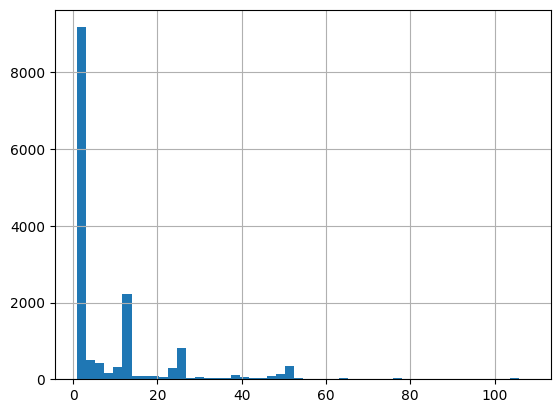

In [527]:
upper = anime_processed["Episodes"].quantile(0.99)

anime_processed[anime_processed["Episodes"] <= upper]["Episodes"].hist(bins=50)

---
We can observe that there are many animes with a number of episodes between 1-12.

The large number of animes with only 1 episode is due to them being movies, OVAs, or other types of special episodes.

---

#### Ranked

In [528]:
anime_processed["Ranked"] = anime_processed["Ranked"].str.replace("#", "")
anime_processed["Ranked"] = pd.to_numeric(anime_processed["Ranked"], errors="coerce")

In [529]:
anime_processed.sort_values("Ranked")[["Name", "Ranked"]].head(20)

,Name,Ranked
17548,"The Sun, Moon and Stars",0.0
16761,Koukaku Kidoutai: SAC_2045 2nd Season,0.0
3971,Fullmetal Alchemist: Brotherhood,1.0
15926,Shingeki no Kyojin: The Final Season,2.0
5683,Steins;Gate,3.0
14963,Shingeki no Kyojin Season 3 Part 2,4.0
9913,GintamaÂ°,5.0
6474,Hunter x Hunter (2011),6.0
6006,Gintama',7.0
741,Ginga Eiyuu Densetsu,7.0


In [530]:
anime_processed["Ranked"] = anime_processed["Ranked"].replace(0, pd.NA)

In [531]:
anime_processed["Ranked"].isnull().sum()

np.int64(143)

---
The Ranked variable includes values equal to 0, which represent entries that are not ranked. These values were treated as missing data. 

Additionally, duplicate ranking values were observed, which is expected due to ties in score and therefore were retained.

---

In [532]:
temp = anime_processed[["Ranked", "Score"]].dropna()

In [533]:
temp[["Ranked", "Score"]].corr()

,Ranked,Score
Ranked,1.000000,-0.972876
Score,-0.972876,1.000000


<Axes: xlabel='Score', ylabel='Ranked'>

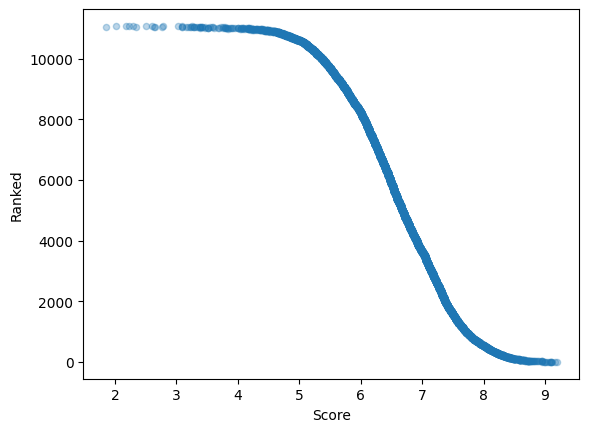

In [534]:
temp.plot.scatter(x="Score", y="Ranked", alpha=0.3)

---
With this, we understand that Ranked is a metric obtained directly from ordering the Scores.

---

#### Name

In [535]:
anime_processed["Name"].value_counts()[anime_processed["Name"].value_counts() > 1]

Name
Hinamatsuri             2
Youkoso! Ecolo Shima    2
Name: count, dtype: int64

In [536]:
anime_processed[anime_processed["Name"] == "Hinamatsuri"]

,MAL_ID,Name,Score,Type,Episodes,Aired,Studios,Source,Duration,Rating,...,Shounen,Shounen Ai,Slice of Life,Space,Sports,Super Power,Supernatural,Thriller,Vampire,Yaoi
12826,35102,Hinamatsuri,6.79,OVA,1.0,Unknown,Unknown,Other,19 min.,G - All Ages,...,0,0,0,0,0,0,0,0,0,0
13540,36296,Hinamatsuri,8.21,TV,12.0,"Apr 6, 2018 to Jun 22, 2018",feel.,Manga,23 min. per ep.,PG-13 - Teens 13 or older,...,0,0,1,0,0,0,1,0,0,0


In [537]:
anime_processed[anime_processed["Name"] == "Hinamatsuri"]

,MAL_ID,Name,Score,Type,Episodes,Aired,Studios,Source,Duration,Rating,...,Shounen,Shounen Ai,Slice of Life,Space,Sports,Super Power,Supernatural,Thriller,Vampire,Yaoi
12826,35102,Hinamatsuri,6.79,OVA,1.0,Unknown,Unknown,Other,19 min.,G - All Ages,...,0,0,0,0,0,0,0,0,0,0
13540,36296,Hinamatsuri,8.21,TV,12.0,"Apr 6, 2018 to Jun 22, 2018",feel.,Manga,23 min. per ep.,PG-13 - Teens 13 or older,...,0,0,1,0,0,0,1,0,0,0


---
We observed a small number of entries with the same name, but after analyzing it deeper, we observed that, in both cases, one corresponds to the original anime, and the other one to an OVA.

---

#### Source (*)

In [538]:
anime_processed["Source"].value_counts()

Source
Original         4904
Manga            3419
Game              822
Light novel       703
Other             556
Novel             474
Visual novel      366
Music             312
4-koma manga      280
Web manga         234
Picture book      139
Book              110
Card game          58
Radio              12
Digital manga       9
Name: count, dtype: int64

In [539]:
top_sources = ["Original", "Manga", "Game", "Light novel", "Book"]

In [540]:
anime_processed["Source_grouped"] = anime_processed["Source"].apply(
    lambda x: x if x in top_sources else "Other"
)

In [541]:
anime_processed = anime_processed.drop(columns=["Source"])

---
After reducing the number of sources to 6 main groups, we could encode it, but right now we will leave it like this and encode it if needed when modelling.

---

#### Popularity

In [542]:
anime_processed["Popularity"].describe()

count    15675.000000
mean      8810.961148
std       5218.388112
min          0.000000
25%       4028.500000
50%       9054.000000
75%      13422.500000
max      17560.000000
Name: Popularity, dtype: float64

In [543]:
anime_processed["Popularity"].head()

0      39
1     518
2     201
3    1467
4    4369
Name: Popularity, dtype: int64

In [544]:
anime_processed.sort_values("Popularity")[["Name", "Popularity"]].head(20)

,Name,Popularity
16761,Koukaku Kidoutai: SAC_2045 2nd Season,0
17548,"The Sun, Moon and Stars",0
1393,Death Note,1
7449,Shingeki no Kyojin,2
3971,Fullmetal Alchemist: Brotherhood,3
6614,Sword Art Online,4
10451,One Punch Man,5
11185,Boku no Hero Academia,6
8646,Tokyo Ghoul,7
10,Naruto,8


In [545]:
anime_processed["Popularity"] = anime_processed["Popularity"].replace(0, pd.NA)

In [559]:
anime.loc[
    [16761, 17548],
    ["Name", "Members", "Favorites", "Watching", "Completed", "Dropped"]
]

,Name,Members,Favorites,Watching,Completed,Dropped
16761,Koukaku Kidoutai: SAC_2045 2nd Season,1,4,0,0,0
17548,"The Sun, Moon and Stars",1,0,0,0,0


---
As we have observed this entries at the top of both Popularity and Ranked:
    - 16761	Koukaku Kidoutai: SAC_2045 2nd Season	0
    - 17548	The Sun, Moon and Stars	0

These entry show extremely low user interactions their are excluded of the ranking and popularity, so to avoid including noise in our model, and as this only represents 2 entries of the whole dataset, we will remove both.

---

In [547]:
anime_processed = anime_processed.dropna(subset=["Ranked"])

In [548]:
anime_processed[["Popularity", "Members"]].corr()

,Popularity,Members
Popularity,1.000000,-0.430718
Members,-0.430718,1.000000


In [549]:
anime_processed.sort_values("Members", ascending=False)[["Name", "Members", "Popularity"]].head(10)

,Name,Members,Popularity
1393,Death Note,2589552,1
7449,Shingeki no Kyojin,2531397,2
3971,Fullmetal Alchemist: Brotherhood,2248456,3
6614,Sword Art Online,2214395,4
10451,One Punch Man,2123866,5
11185,Boku no Hero Academia,1909814,6
8646,Tokyo Ghoul,1895488,7
10,Naruto,1830540,8
5683,Steins;Gate,1771162,9
8148,No Game No Life,1751054,10


<Axes: xlabel='Popularity', ylabel='Members'>

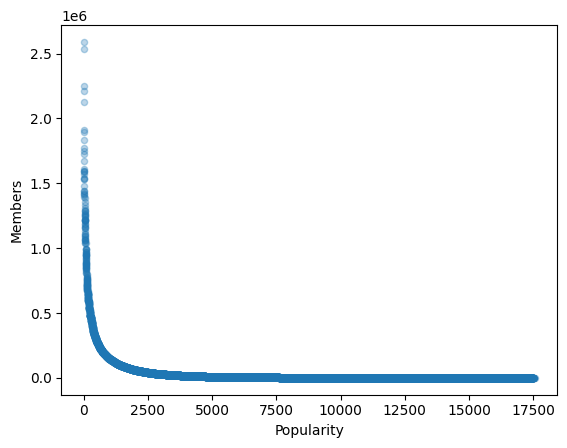

In [550]:
anime_processed.plot.scatter(x="Popularity", y="Members", alpha=0.3)

---
With this, we understand that Popularity is a metric obtained directly from ordering the animes based on the Members.

---

#### Favorites

In [560]:
anime_processed["Favorites"].describe()

count     15532.000000
mean        502.696240
std        4196.114302
min           0.000000
25%           0.000000
50%           2.000000
75%          32.000000
max      183914.000000
Name: Favorites, dtype: float64

<Axes: >

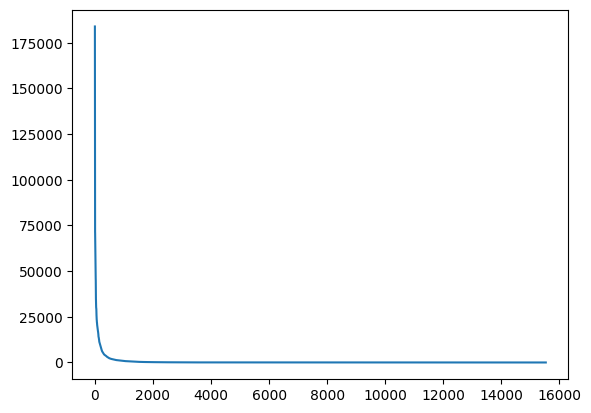

In [578]:
favorites_sorted = anime_processed["Favorites"].sort_values(ascending=False).reset_index(drop=True)

favorites_sorted.plot()

---
We observe that a few animes are loved by a large numbers of users, while the majority of the animes are loved by a small percentage of the user base.

---

<Axes: xlabel='Members', ylabel='Favorites'>

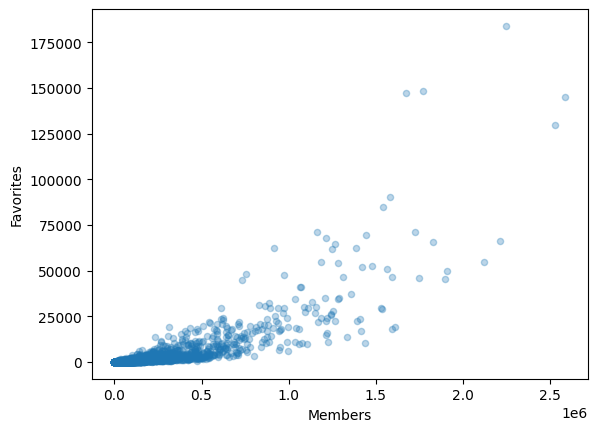

In [564]:
anime_processed.plot.scatter(x="Members", y="Favorites", alpha=0.3)

---
We observe a positive relationship between Members and Favorites. This indicates that more popular animes tend to accumulate more favorites. However, the relationship is not linear, this suggest differences in user preference intensity.

So, to account for that, we will add a normalized feature (Favorites / Members to capture relative user engagement.

---

In [579]:
anime_processed["Fav_ratio"] = anime_processed["Favorites"] / anime_processed["Members"]

In [ ]:
anime_processed["Fav_ratio"] = anime_processed["Fav_ratio"].fillna(0)